In [1]:
import os

from libs.multilevel_squeme.coarsening import coarsen_chain
from libs.multilevel_squeme import partition_graph_metis
from libs.multilevel_squeme.quantum_annealing import (
    lift_partition_to_finer,
    recursive_kway_anneal
)

from libs.utils import (
    load_mtx,
    matrix_to_graph,
    summarize_generic
)

In [2]:
data_dir = os.path.abspath(os.path.join(os.getcwd(), "..", "data"))

k_matrix_path = os.path.join(data_dir, "hybrid_ma.classical.fem.matrix_k.mtx")
print("Using data_dir:", data_dir)

Using data_dir: /home/operation/reps/FEM-Graph-Partitioning-Toolkit-Multilevel-METIS-/data


In [3]:
# Load matrices
A_K = load_mtx(k_matrix_path, 'K')

if A_K is None:
    raise RuntimeError("Matrix load failed; check file paths printed above.")

print(f"Loaded: K | shape={A_K.shape}, nnz={A_K.nnz}")

Loaded: K | shape=(960, 960), nnz=30282
Loaded: K | shape=(960, 960), nnz=30282


In [4]:
# Build graphs from matrices
diag_K = A_K.diagonal()

has_m_matrix = False  # Set to True if M matrix is available

# Map the matrix into the graph (only the K matrix is needed since we are partitioning most based on connectivity)
G_K = matrix_to_graph(A_K, symmetrize='sum', drop_diagonal=True, abs_weights=True, node_vweight='diag', diag=diag_K)

print(f"K: |V|={G_K.number_of_nodes()}, |E|={G_K.number_of_edges()}")

K: |V|=960, |E|=14661


In [5]:
# VALIDATION STEP 1: Matrix to Graph Conversion
from libs.validation_pipeline import validate_matrix_to_graph

validate_matrix_to_graph(
    matrix_k=A_K,
    matrix_m=A_M if has_m_matrix else None,
    graph_k=G_K,
    diag_k=diag_K,
    verbose=False
)

✅ STEP 1 VALIDATION PASSED: Matrix to Graph conversion is valid


In [6]:
# Parameters for the coarsening
coarsen_limit = 300
max_levels = 10
weight = 'weight'
strategy = 'sorted'  # Options: 'random', 'sorted', 'modified', 'light'
coarsen_ratio = 2  # Stop if reduction ratio > 0.80

# Max node weight constraint (optional)
# Calculate based on target partitions: 1.5 * (total_weight / K_TARGET)
total_weight = sum(G_K.nodes[n].get('vweight', 1.0) for n in G_K.nodes())
K_TARGET = 32  # number of parts desired
max_node_weight = 1.0 * (total_weight / K_TARGET)

# Parameters for the annealling
BALANCE_LAMBDA = 2
NUM_READS = 1000
BALANCE_TOLERANCE = 2.0  # Allow ±5% variation in partition sizes (like METIS ubfactor)

In [7]:
graphs, maps = coarsen_chain(
    G_K, 
    trial_seed=42, 
    coarsen_limit=coarsen_limit, 
    max_levels=max_levels, 
    weight=weight,
    strategy=strategy,
    coarsen_ratio=coarsen_ratio,
    max_node_weight=max_node_weight
)

print(f"Coarsening completed: {len(graphs)} levels")
print(f"Original graph: {graphs[0].number_of_nodes()} nodes")
print(f"Coarsest graph: {graphs[-1].number_of_nodes()} nodes")

Coarsening completed: 3 levels
Original graph: 960 nodes
Coarsest graph: 251 nodes


In [8]:
# VALIDATION STEP 2: Coarsening Phase
from libs.validation_pipeline import validate_coarsening_phase

validate_coarsening_phase(
    original_graph=G_K,
    coarse_chain=graphs,
    maps=maps,
    verbose=False
)

✅ STEP 2 VALIDATION PASSED: Coarsening phase is valid


In [9]:
Gc, Gc_map = graphs[-1], maps[-1]
print(f"K: |V|={Gc.number_of_nodes()}, |E|={Gc.number_of_edges()}")

# Run recursive k-way annealing and capture first QUBO for validation
part_k_coarse_QA, first_qubo, first_subgraph = recursive_kway_anneal(
    Gc, 
    K_TARGET,
    balance_weight=BALANCE_LAMBDA,
    num_reads=NUM_READS,
    choose_by='vweight',
    balance_tolerance=BALANCE_TOLERANCE,
    seed=42,
    return_first_qubo=True  # Return QUBO for validation
)

print(f"QUBO captured for validation: {len(first_qubo)} coefficients")

K: |V|=251, |E|=2991


QUBO captured for validation: 31626 coefficients


In [10]:
# VALIDATION STEP 3: QUBO Formulation
from libs.validation_pipeline import validate_qubo_phase

# Validate QUBO formulation on the first bisection subgraph
validate_qubo_phase(
    graph=first_subgraph,
    Q=first_qubo,
    num_partitions=2,  # QUBO is always for 2-way partition
    verbose=False
)

✅ STEP 3 VALIDATION PASSED: QUBO formulation is valid


In [11]:
# VALIDATION STEP 4: Recursive Annealing Phase (on coarse graph)
from libs.validation_pipeline import validate_recursive_annealing_phase

validate_recursive_annealing_phase(
    graph=Gc,
    partition=part_k_coarse_QA,
    num_partitions=K_TARGET,
    verbose=False
)

✅ STEP 4 VALIDATION PASSED: Recursive annealing partition is valid


In [12]:
# Lift back to original nodes
part_k_orig = lift_partition_to_finer(graphs, maps, part_k_coarse_QA)

In [13]:
# VALIDATION STEP 5: Partition Lifting Phase
from libs.validation_pipeline import validate_lifting_phase

validate_lifting_phase(
    original_graph=G_K,
    coarse_chain=graphs,
    coarse_partition=part_k_coarse_QA,
    final_partition=part_k_orig,
    maps=maps,
    verbose=False
)

✅ STEP 5 VALIDATION PASSED: Partition lifting is valid


In [14]:
# Summarize on original graph
summarize_generic(G_K, part_k_orig, f'K [quantum k={K_TARGET}]')

print("\n")

# Baseline METIS comparison for the same K_TARGET
metis_part_K = partition_graph_metis(G_K, nparts=K_TARGET, weight='weight', seed=42, verbose=0)
summarize_generic(G_K, metis_part_K, f"METIS K [{K_TARGET}]")

# Choose which partition to use for reordering (quantum or METIS)
chosen_partition = metis_part_K  # or part_k_orig

K [quantum k=32]: cut=42137.9318, parts=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31], per=[960.9722416314019, 1053.0783288182727, 1070.3382863651912, 1018.36846288629, 1137.137379953884, 1038.1644799665664, 1155.2799892370608, 1011.1549035348046, 1126.079067037369, 1019.4195356870445, 1064.6118432201076, 1018.3700652312975, 1085.571763648103, 1055.6011936144725, 1022.3073485577388, 957.4216203908511, 1109.8313641937054, 1134.2559973229809, 1066.1591352888454, 1121.9701932527798, 1085.6943625098293, 1090.6618669019354, 1058.0209641362194, 1105.8710142930345, 1082.2977645179851, 1066.3753480105784, 1006.7797209386946, 1013.1710963168665, 960.6221783038949, 961.7305384603246, 996.1802812901196, 992.3666383236028], total=33645.8650
Per difference: 197.85836884620971 Max per: 1155.2799892370608 Min per: 957.4216203908511


METIS K [32]: cut=27546.6626, parts=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 1

## Matrix Reordering Based on Partition

Apply the partition permutation to reorder the K and M matrices so that nodes in the same partition are grouped together.

In [15]:
# Matrix reordering and export
from libs.matrix_reordering import reorder_and_save_matrices

# Load M matrix if available
m_matrix_path = os.path.join(data_dir, "hybrid_ma.classical.fem.matrix_m.mtx")
try:
    A_M = load_mtx(m_matrix_path, 'M')
    has_m_matrix = A_M is not None
    if has_m_matrix:
        print(f"Loaded M matrix: shape={A_M.shape}, nnz={A_M.nnz}")
except:
    A_M = None
    has_m_matrix = False
    print("M matrix not found or couldn't be loaded")

# Reorder and save matrices
result = reorder_and_save_matrices(
    matrix_k=A_K,
    partition=chosen_partition,
    k_target=K_TARGET,
    output_dir=os.path.join(os.getcwd(), "..", "results"),
    partition_method="quantum",
    matrix_m=A_M if has_m_matrix else None,
    save_permutation=True,
    verbose=False
)

# Extract results for validation
permutation = result['permutation']
A_K_permuted = result['matrix_k_permuted']
A_M_permuted = result['matrix_m_permuted']

Loaded: M | shape=(960, 960), nnz=10098
Loaded M matrix: shape=(960, 960), nnz=10098


In [16]:
# VALIDATION STEP 6: Matrix Permutation
from libs.validation_pipeline import validate_matrix_permutation

# Validate K matrix permutation
validate_matrix_permutation(
    original_matrix=A_K,
    permuted_matrix=A_K_permuted,
    permutation=permutation,
    partition=chosen_partition,
    verbose=True
)

# Validate M matrix permutation if present
if has_m_matrix:
    print("\n" + "="*80)
    print("STEP 6b: MATRIX M PERMUTATION VALIDATION")
    print("="*80)
    validate_matrix_permutation(
        original_matrix=A_M,
        permuted_matrix=A_M_permuted,
        permutation=permutation,
        partition=chosen_partition,
        verbose=True
    )

STEP 6: MATRIX PERMUTATION VALIDATION
✓ Checking matrix dimensions...
  ✓ Matrix dimensions preserved: (960, 960)
✓ Checking sparsity structure...
  ✓ Sparsity preserved: 30282 non-zeros (3.29% density)
✓ Checking permutation array...
  ✓ Permutation is valid: length=960
✓ Checking permutation consistency with partition...
  ✓ Permutation groups nodes by partition (k=32 blocks)
    Partition 0: indices [0, 24] (25 nodes)
    Partition 1: indices [25, 50] (26 nodes)
    Partition 2: indices [51, 73] (23 nodes)
    Partition 3: indices [74, 110] (37 nodes)
    Partition 4: indices [111, 132] (22 nodes)
    Partition 5: indices [133, 161] (29 nodes)
    Partition 6: indices [162, 192] (31 nodes)
    Partition 7: indices [193, 229] (37 nodes)
    Partition 8: indices [230, 249] (20 nodes)
    Partition 9: indices [250, 276] (27 nodes)
    Partition 10: indices [277, 305] (29 nodes)
    Partition 11: indices [306, 340] (35 nodes)
    Partition 12: indices [341, 373] (33 nodes)
    Partition

## Visualize Block Structure

Optional: Visualize the sparsity pattern to see the block structure created by partitioning.

MATRIX VISUALIZATION

[1/2] K Matrix Visualization
--------------------------------------------------------------------------------
Plotting original K matrix...


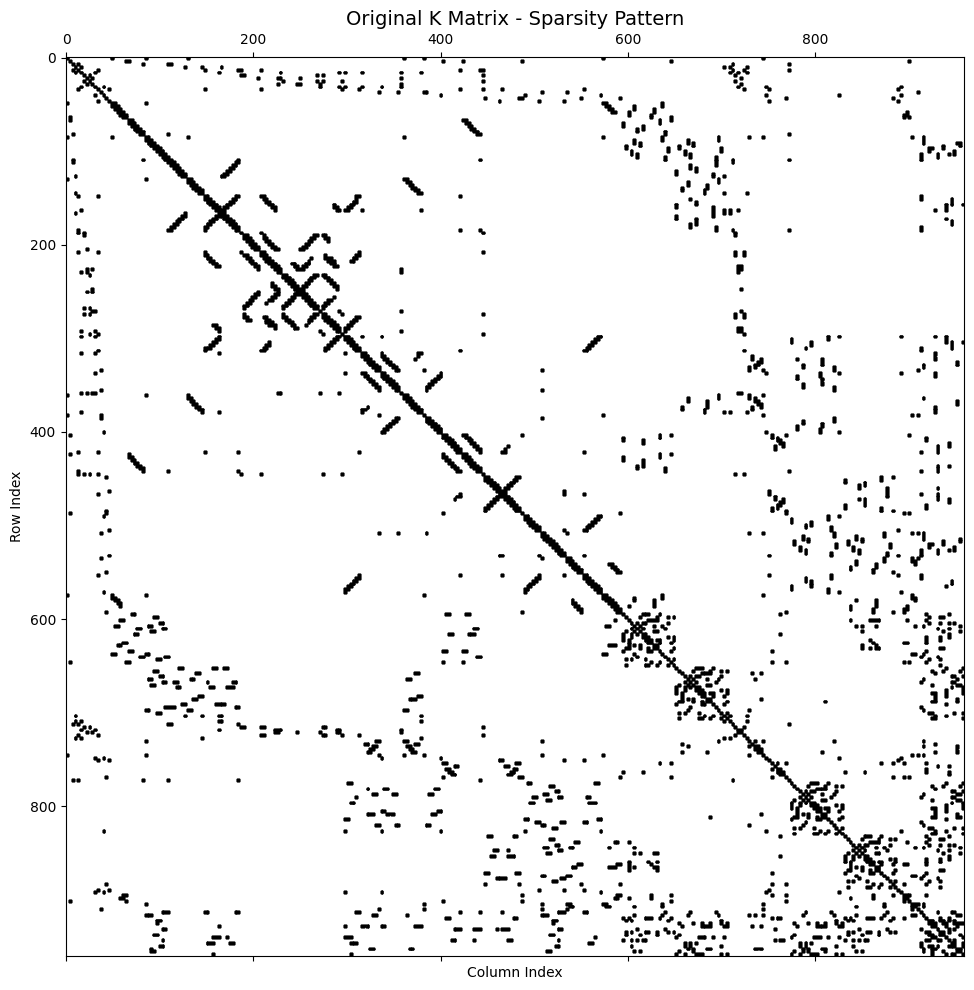

Plotting reordered K matrix with partition boundaries...


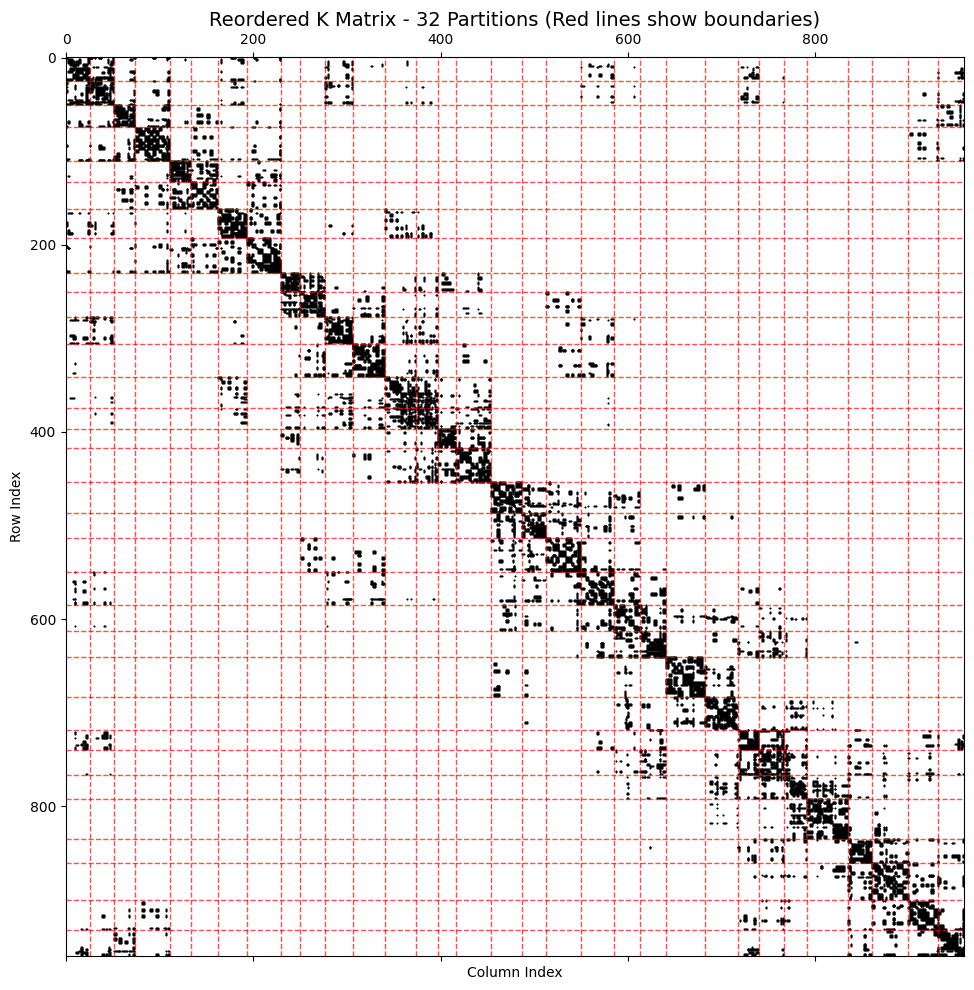


✓ Red dashed lines show the 32 partition boundaries
✓ Notice the block structure: nodes within same partition have denser connections

[2/2] M Matrix Visualization
--------------------------------------------------------------------------------
Plotting original M matrix...


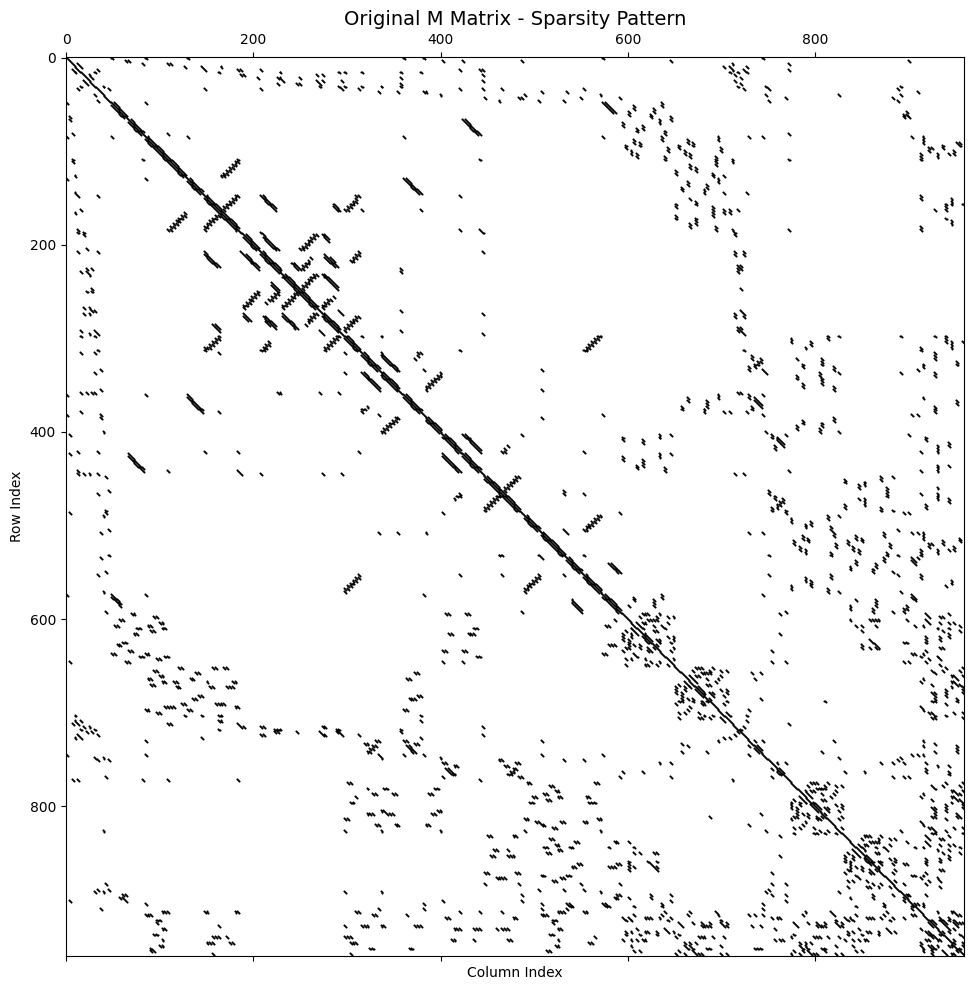

Plotting reordered M matrix with partition boundaries...


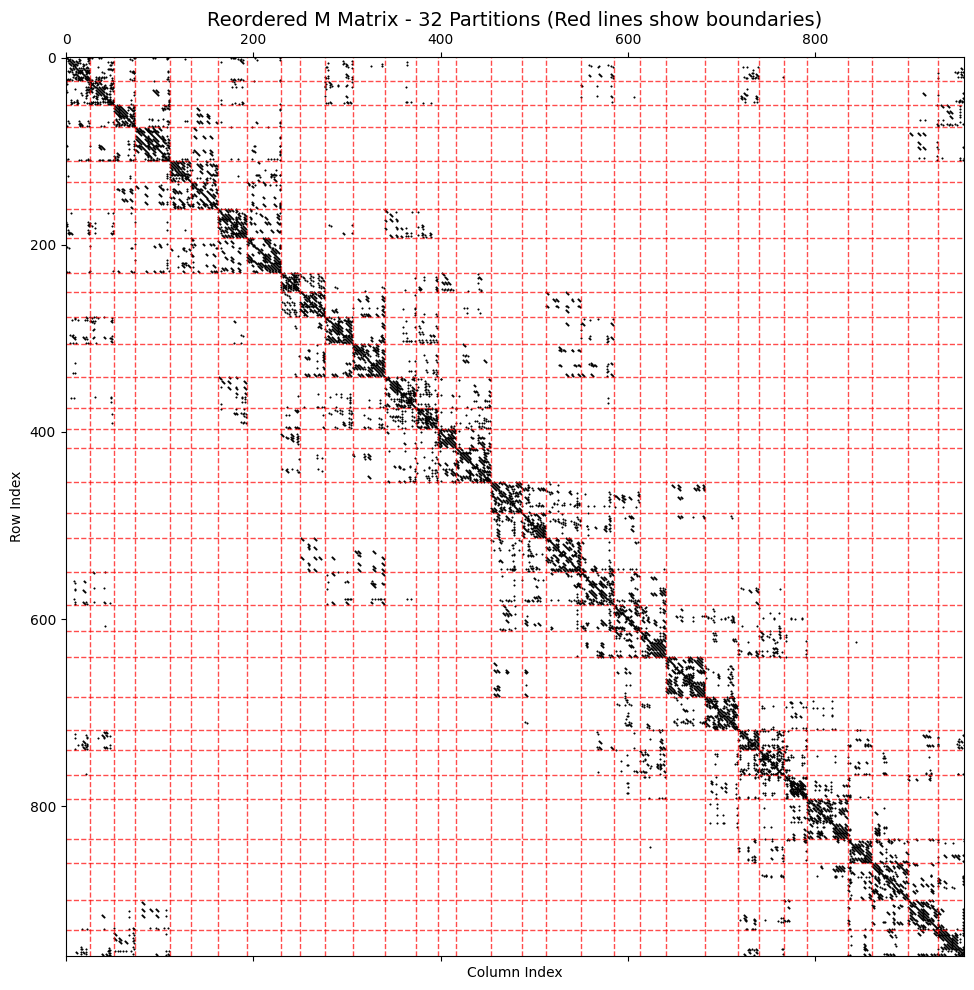


✓ Red dashed lines show the 32 partition boundaries
✓ Notice the block structure: nodes within same partition have denser connections

✅ Visualization completed!


{'k_original': <Figure size 1000x1000 with 1 Axes>,
 'k_permuted': <Figure size 1000x1000 with 1 Axes>,
 'm_original': <Figure size 1000x1000 with 1 Axes>,
 'm_permuted': <Figure size 1000x1000 with 1 Axes>}

In [17]:
# Visualize matrix sparsity patterns with partition boundaries
from libs.visualization import visualize_all_matrices

visualize_all_matrices(
    matrix_k_original=A_K,
    matrix_k_permuted=A_K_permuted,
    partition=chosen_partition,
    k_target=K_TARGET,
    matrix_m_original=A_M if has_m_matrix else None,
    matrix_m_permuted=A_M_permuted if has_m_matrix else None,
    figsize=(10, 10),
    markersize=0.5
)

## Full Pipeline Validation

Run complete validation of entire QGP pipeline.

In [19]:
# FULL PIPELINE VALIDATION
from libs.validation_pipeline import validate_full_pipeline

validate_full_pipeline(
    # Step 1: Matrix to Graph
    matrix_k=A_K,
    matrix_m=A_M if has_m_matrix else None,
    graph_k=G_K,
    diag_k=diag_K,

    # Step 2: Coarsening
    coarse_chain=graphs,
    maps=maps,

    # Step 3: QUBO Formulation
    Q=first_qubo,
    qubo_graph=first_subgraph,  # Use the first bisection subgraph
    num_partitions_qubo=2,  # QUBO is for 2-way partition

    # Step 4: Recursive Annealing
    coarse_partition=part_k_coarse_QA,
    num_partitions=K_TARGET,

    # Step 5: Lifting
    final_partition=part_k_orig,

    # Step 6: Matrix Permutation
    permuted_matrix_k=A_K_permuted,
    permuted_matrix_m=A_M_permuted if has_m_matrix else None,
    permutation=permutation,
    partition_for_permutation=chosen_partition,  # Use the partition that was used to create the permutation
    
    # Control
    verbose=False,
    skip_steps=[]  # Validate all 6 steps including QUBO
)

FULL PIPELINE VALIDATION

✅ STEP 1 VALIDATION PASSED: Matrix to Graph conversion is valid

✅ STEP 2 VALIDATION PASSED: Coarsening phase is valid

✅ STEP 3 VALIDATION PASSED: QUBO formulation is valid

✅ STEP 4 VALIDATION PASSED: Recursive annealing partition is valid

✅ STEP 5 VALIDATION PASSED: Partition lifting is valid

✅ STEP 6 VALIDATION PASSED: Matrix permutation is valid

✅ STEP 6 VALIDATION PASSED: Matrix permutation is valid

✅ FULL PIPELINE VALIDATION PASSED
All 6 validation steps passed successfully.
✅ STEP 6 VALIDATION PASSED: Matrix permutation is valid

✅ STEP 6 VALIDATION PASSED: Matrix permutation is valid

✅ FULL PIPELINE VALIDATION PASSED
All 6 validation steps passed successfully.
